# 第2回　分子を数値にする：RDKit記述子とMorganフィンガープリント

高分子の構造は `*Oc1cc2c(cc1O*)C1(...)` のような SMILES 文字列で与えられます。機械学習モデルは文字列をそのままでは扱えないので、**固定長の数値ベクトル**に変換しなければなりません。この変換を**化学表現（chemical representation）**と呼び、予測精度を左右する重要な設計判断です。

本回は論文 Fig.1 の **Step 2** に対応します。

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ARIM-ACADEMY-2026/Advanced_Tutorial_11_Polymer-Gas-Membrane/blob/main/02_chemical_representation.ipynb)

## 本ノートブックについて

| 項目 | 内容 |
| --- | --- |
| **対象読者** | 第1回を終えた方。RDKit は初めてでも構いません |
| **前提知識** | Pythonの基礎文法。化学構造式が読めると理解しやすいですが必須ではありません |
| **本回で学ぶこと** | ①RDKitで分子を読み込み描画する、②分子記述子の計算と前処理、③Morganフィンガープリント（MFF）の仕組みと実装、④2つの表現の性質の違い |
| **所要時間** | 約50分（記述子の計算に1〜2分かかります） |
| **動作環境** | Python 3.10以上、rdkit / pandas / numpy / matplotlib / scikit-learn |
| **データ** | `code/datasets/datasetA_imputed_all.csv`（SMILES）、`datasetAX_desc.csv`・`datasetAX_fing.csv`（著者らが計算済みの特徴量） |
| **ライセンス** | 論文 CC BY-NC 4.0。原著コード `code/step2_generate_Xfeatures.py` を教材向けに書き直しています |

> **本回のゴール**：著者らが公開している `datasetAX_fing.csv` を、自分の手で SMILES から**ビット単位で完全に再現**します。「論文の特徴量が本当に再現できるか」を確かめることは、追試の第一歩です。

---
## 0. セットアップ

In [1]:
# Google Colab で実行する場合のセットアップ（ローカル環境では何もしない）
import os
import subprocess
import sys

IN_COLAB = 'google.colab' in sys.modules
REPO_DIR = 'Advanced_Tutorial_11_Polymer-Gas-Membrane'
PACKAGES = ['rdkit']

if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_11_Polymer-Gas-Membrane.git'], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + PACKAGES, check=False)
    print('Colab setup finished. cwd =', os.getcwd())
else:
    print('Running locally. cwd =', os.getcwd())

Running locally. cwd = /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw, Descriptors
from rdkit.Chem import rdFingerprintGenerator

from module.pgm_setup import setup_notebook, print_library_versions, GAS_NAMES
from module.pgm_data import load_dataset_a, load_features
from module.pgm_features import (
    smiles_to_mols, compute_descriptors, drop_uninformative_descriptors,
    identify_legacy_descriptor_columns, build_mff_vocabulary, compute_mff,
    draw_substructure, find_molecule_with_substructure,
    MORGAN_RADIUS, MAX_ZEROS,
)

PATHS = setup_notebook()
OUTPUT_DIR = PATHS['OUTPUT_DIR']
DATA_DIR = PATHS['DATA_DIR']
print()
print_library_versions(('numpy', 'pandas', 'rdkit', 'sklearn'))

Environment      : local
Project root     : /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML
Dataset directory: /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML/code/datasets
Output directory : /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML/output

numpy        2.2.6
pandas       2.3.3
rdkit        2026.03.5


sklearn      1.7.2


> **本回で使うヘルパー**：`module/pgm_features.py`
>
> 原著の `code/step2_generate_Xfeatures.py` を次の3点だけ変更して移植しています。いずれも化学・機械学習の中身ではなく実装上の都合なので、モジュール側に置きました。
>
> 1. 非推奨になった `AllChem.GetMorganFingerprint` を `rdFingerprintGenerator` に置換
> 2. 部分構造の索引探索を DataFrame 全走査（O(N²)）から辞書引き（O(1)）に変更
> 3. `os.chdir` による作業ディレクトリ書き換えを廃止し、パスを引数で受け取る形に変更

---
## 1. SMILES を分子として読み込む

まずデータを読み、代表的な高分子の構造を描いてみます。

In [3]:
dataset_a = load_dataset_a(DATA_DIR)
mols, valid_mask = smiles_to_mols(dataset_a['Smiles'])

print(f"高分子数: {len(dataset_a)}")
print(f"RDKit がパースできた分子: {valid_mask.sum()} / {len(dataset_a)}")
assert valid_mask.all(), "パースできない SMILES があります"

高分子数: 353
RDKit がパースできた分子: 353 / 353


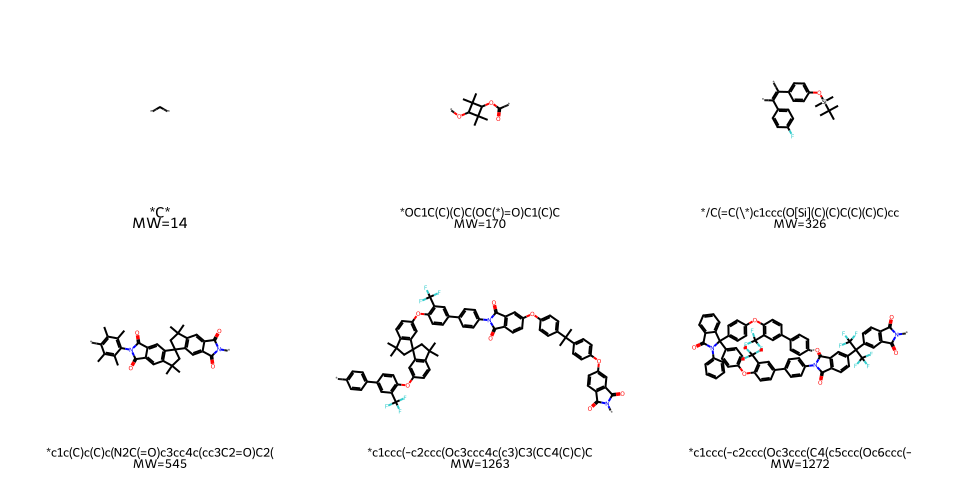

In [4]:
# 分子量の小さいものから大きいものまで代表を選んで描画する
molecular_weights = np.array([Descriptors.MolWt(m) for m in mols])
order = np.argsort(molecular_weights)
picked = [order[0], order[len(order) // 4], order[len(order) // 2],
          order[3 * len(order) // 4], order[-2], order[-1]]

legends = [f"{dataset_a['Smiles'].iloc[i][:38]}\nMW={molecular_weights[i]:.0f}" for i in picked]
image = Draw.MolsToGridImage([mols[i] for i in picked], molsPerRow=3,
                             subImgSize=(320, 240), legends=legends)
image

**図1**　Dataset A に含まれる高分子の繰り返し単位（分子量の小さい順に代表を6つ）。`*` は隣の繰り返し単位との結合点を表します。左上のポリエチレン（`*C*`）のような単純なものから、複雑な芳香族多環構造まで幅が広いことが分かります。

透過係数が高い PIM 系の高分子は、右下のような**かさ高くねじれた剛直骨格**を持ちます。このような構造は高分子鎖が効率よく詰まるのを妨げ、自由体積（=ガスの通り道）を増やします。

In [5]:
# O2 透過係数が高い順に上位を並べてみる
from module.pgm_data import load_dataset_a_raw

raw = load_dataset_a_raw(DATA_DIR)
top_o2 = (raw.dropna(subset=['O2'])
             .sort_values('O2', ascending=False)[['Name', 'Smiles', 'O2', 'N2', 'Year']]
             .head(8)
             .reset_index(drop=True))
top_o2

,Name,Smiles,O2,N2,Year
0,poly(hex-1-ene),*CC(*)CCCC,72000.0,27000.0,1984
1,polycyclohexene,*C1CCCCC1*,61000.0,20000.0,1984
2,"Poly(diphenyl acetylene) 2e p,m-F",*/C(=C(\*)c1ccc2c(c1)C(C)(C)CC2(C)C)c1ccc(F)c(...,18700.0,16600.0,2008
3,Poly(diphenyl acetylene) 2b p-F,*/C(=C(\*)c1ccc2c(c1)C(C)(C)CC2(C)C)c1ccc(F)cc1,17900.0,15600.0,2008
4,"Poly(diphenyl acetylene) 2f m,m-F",*/C(=C(\*)c1ccc2c(c1)C(C)(C)CC2(C)C)c1cc(F)cc(...,15200.0,13100.0,2008
5,Poly(diphenyl acetylene) Poly 1,*/C(=C(\*)c1ccc2c(c1)C(C)(C)CC2(C)C)c1ccccc1,14400.0,11600.0,2007
6,Poly(diphenyl acetylene) 2c m-F,*/C(=C(\*)c1ccc2c(c1)C(C)(C)CC2(C)C)c1cccc(F)c1,14300.0,12000.0,2008
7,Poly(diphenyl acetylene) 2k none,*/C(=C(\*)c1ccc2c(c1)C(C)(C)C(C)(C)C2(C)C)c1cc...,12900.0,10400.0,2008


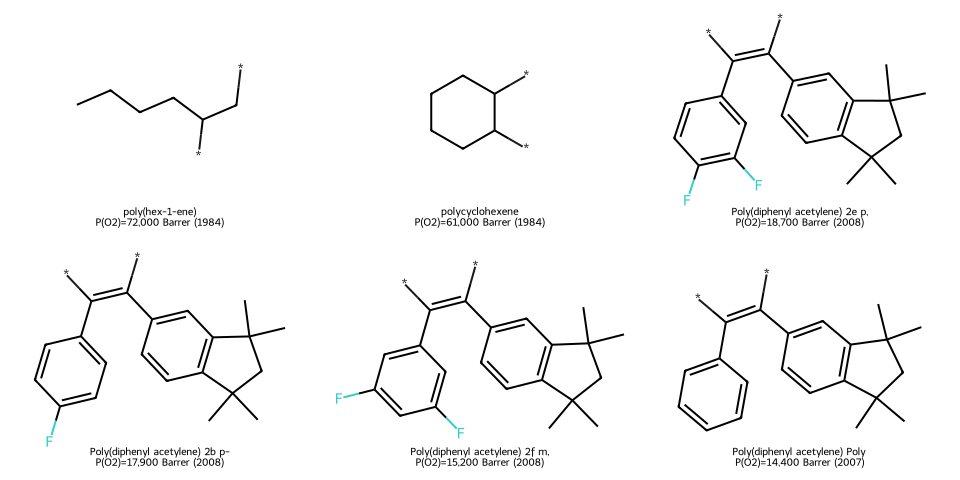

In [6]:
top_mols = [Chem.MolFromSmiles(s) for s in top_o2['Smiles'].head(6)]
top_legends = [f"{name[:30]}\nP(O2)={p:,.0f} Barrer ({year})"
               for name, p, year in zip(top_o2['Name'], top_o2['O2'], top_o2['Year'])]
Draw.MolsToGridImage(top_mols, molsPerRow=3, subImgSize=(320, 240), legends=top_legends[:6])

**図2**　Dataset A で O₂ 透過係数が高い上位6件。

3位以下に並ぶ **poly(diphenylacetylene)** 系（`*/C(=C(\*)...)...`）は、主鎖が二重結合で剛直かつ、かさ高い置換基で鎖の充填を妨げる典型的な超透過性高分子です。第4回の SHAP 解析で「二重結合炭素に芳香環が付いた部分構造（列1432, 822）が透過性を上げる」という結論が出ますが、その根拠になっているのがこの一群です。

一方、**上位2件は少し注意が必要**です。poly(hex-1-ene) と polycyclohexene は柔軟な脂肪族主鎖を持つ普通の高分子で、文献で報告される O₂ 透過係数は通常もっと小さい値です。それが 72,000 / 61,000 Barrer というpoly(1-トリメチルシリルプロピン)（PTMSP, 10,000 Barrer, 12位）を大きく上回る値として入っている点は、データベースの転記や単位の扱いを疑ってみる価値があります。

**実データを使う教材として重要なのは、この種の外れ値を「そういうものだ」と流さないことです。**

本研究の学習データは複数の文献値を機械的に集約したもので、こうした疑わしいエントリもそのまま含まれています。第3回でモデルの残差を見るとき、この2件がどう振る舞うか確認してみてください。

---
## 2. 表現その1：RDKit 分子記述子

**分子記述子（molecular descriptor）**は、分子の物理化学的な性質を1つの数値にまとめたものです。分子量、環の数、極性表面積、logP（脂溶性）など、化学者が昔から使ってきた指標が中心で、**それぞれの意味が解釈しやすい**のが利点です。

RDKit は数百種の記述子を一括で計算できます。

In [7]:
all_descriptor_names = [name for name, _ in Descriptors.descList]
print(f"現在の RDKit が提供する記述子の数: {len(all_descriptor_names)}")
print()
print("例（先頭20個）:")
for i in range(0, 20, 4):
    print('  ' + '  '.join(f'{n:<24s}' for n in all_descriptor_names[i:i + 4]))

現在の RDKit が提供する記述子の数: 217

例（先頭20個）:
  MaxAbsEStateIndex         MaxEStateIndex            MinAbsEStateIndex         MinEStateIndex          
  qed                       SPS                       MolWt                     HeavyAtomMolWt          
  ExactMolWt                NumValenceElectrons       NumRadicalElectrons       MaxPartialCharge        
  MinPartialCharge          MaxAbsPartialCharge       MinAbsPartialCharge       FpDensityMorgan1        
  FpDensityMorgan2          FpDensityMorgan3          BCUT2D_MWHI               BCUT2D_MWLOW            


In [8]:
%%time
# 353 分子 x 全記述子を計算する（1〜2分かかります）
descriptors_all = compute_descriptors(mols)
print(f"生の記述子行列: {descriptors_all.shape}")

生の記述子行列: (353, 217)
CPU times: user 9.26 s, sys: 152 ms, total: 9.42 s
Wall time: 8.93 s


### 2.1 使えない列を落とす

全部の記述子がそのまま使えるわけではありません。原著 `step2_generate_Xfeatures.py` と同じく、

1. **欠損（NaN）を含む列**を落とす（一部の記述子は特定の分子で計算に失敗する）
2. **全分子でゼロの列**を落とす（例：このデータには存在しない官能基のカウント）

という2つの前処理をします。

In [9]:
descriptors = drop_uninformative_descriptors(descriptors_all)
n_after_nan = descriptors_all.dropna(axis='columns').shape[1]
print(f"前処理前: {descriptors_all.shape[1]} 列")
print(f"  NaN を含む列を除去 : -{descriptors_all.shape[1] - n_after_nan} 列")
print(f"  全ゼロ列を除去     : -{n_after_nan - descriptors.shape[1]} 列")
print(f"前処理後: {descriptors.shape[1]} 列")
print()
print("論文 Methods 節の記述: 「146 relevant chemical descriptors are calculated」")
print(f"同梱ファイル datasetAX_desc.csv の列数: {load_features(DATA_DIR, 'desc').shape[1]}")

前処理前: 217 列
  NaN を含む列を除去 : -12 列
  全ゼロ列を除去     : -50 列
前処理後: 155 列

論文 Methods 節の記述: 「146 relevant chemical descriptors are calculated」
同梱ファイル datasetAX_desc.csv の列数: 146


論文と同じ手続きを踏んだのに、**論文の146列に対して今回は155列**になりました。差の9列は「論文当時の RDKit には存在しなかった新しい記述子」です（例：`SPS`、`AvgIpc` など）。つまり手続きは同じでも、**ライブラリのバージョンが違うと特徴量の数そのものが変わります**。

この差は次の 2.2 節で正面から扱います。教材として重要な点なので、「論文と数が合わないから何か間違えた」と早合点せずに読み進めてください。

### 2.2 論文の特徴量ファイルと突き合わせる ― 再現性の落とし穴

著者らが計算した `datasetAX_desc.csv` と比べてみます。

In [10]:
reference_desc = load_features(DATA_DIR, 'desc')
print(f"同梱ファイル datasetAX_desc.csv : {reference_desc.shape}")
print(f"今回計算した記述子              : {descriptors.shape}")
print()
print("同梱ファイルの列名（先頭10個）:", list(reference_desc.columns[:10]))
print("同梱ファイルの列名（末尾10個）:", list(reference_desc.columns[-10:]))

同梱ファイル datasetAX_desc.csv : (353, 146)
今回計算した記述子              : (353, 155)

同梱ファイルの列名（先頭10個）: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '14']
同梱ファイルの列名（末尾10個）: ['178', '180', '187', '188', '189', '196', '198', '200', '205', '206']


**同梱ファイルの列名は記述子名ではなく `0`〜`206` という数字**です。これは当時の `Descriptors.descList` における**位置番号**です。

ここに再現性の落とし穴があります。論文が使った RDKit（2020年頃）の記述子は **208個**でしたが、現在の RDKit では**217個**に増えています。つまり**位置番号の意味がズレている**ため、「同梱ファイルの列107」が今の RDKit のどの記述子なのかは、番号からは分かりません。

番号が使えないなら、**値そのものを照合**すればよい、というのがここでの発想です。353分子分の値のベクトルが完全に一致する記述子を、現在の RDKit の217個から探します。

In [11]:
%%time
descriptor_map = identify_legacy_descriptor_columns(reference_desc, descriptors_all)
print(f"名前を特定できた列: {(descriptor_map['n_candidates'] > 0).sum()} / {len(descriptor_map)}")
print(f"候補が2つ以上あった列: {(descriptor_map['n_candidates'] > 1).sum()}")
print(f"一致する記述子が無かった列: {(descriptor_map['n_candidates'] == 0).sum()}")
descriptor_map.head(12)

名前を特定できた列: 143 / 146
候補が2つ以上あった列: 13
一致する記述子が無かった列: 3
CPU times: user 972 ms, sys: 954 μs, total: 973 ms
Wall time: 972 ms


,legacy_index,n_candidates,descriptor_name,all_candidates
0,0,2,MaxAbsEStateIndex,"MaxAbsEStateIndex, MaxEStateIndex"
1,1,1,MinEStateIndex,MinEStateIndex
2,2,2,MaxAbsEStateIndex,"MaxAbsEStateIndex, MaxEStateIndex"
3,3,1,MinAbsEStateIndex,MinAbsEStateIndex
4,4,1,qed,qed
5,5,1,MolWt,MolWt
6,6,1,HeavyAtomMolWt,HeavyAtomMolWt
7,7,1,ExactMolWt,ExactMolWt
8,8,1,NumValenceElectrons,NumValenceElectrons
9,14,1,FpDensityMorgan1,FpDensityMorgan1


In [12]:
# 論文本文で言及されている記述子が正しく復元できているか確認する
paper_claims = {
    15: 'FpDensityMorgan（論文 Fig.3C: correlation group B）',
    16: 'FpDensityMorgan（論文 Fig.3C: correlation group B）',
    107: 'Aliphatic Cycle Counts（論文 Fig.3C: correlation group A）',
    109: 'Aliphatic Cycle Counts（論文 Fig.3C: correlation group A）',
    101: 'VSA_EState8（論文本文「The most important descriptor is VSA_EState8」）',
}
lookup = descriptor_map.set_index('legacy_index')['descriptor_name']
for index, claim in paper_claims.items():
    print(f"列 {index:>3d} -> {lookup[index]:<28s} | 論文の記述: {claim}")

列  15 -> FpDensityMorgan2             | 論文の記述: FpDensityMorgan（論文 Fig.3C: correlation group B）
列  16 -> FpDensityMorgan3             | 論文の記述: FpDensityMorgan（論文 Fig.3C: correlation group B）
列 107 -> NumAliphaticCarbocycles      | 論文の記述: Aliphatic Cycle Counts（論文 Fig.3C: correlation group A）
列 109 -> NumAliphaticRings            | 論文の記述: Aliphatic Cycle Counts（論文 Fig.3C: correlation group A）
列 101 -> VSA_EState8                  | 論文の記述: VSA_EState8（論文本文「The most important descriptor is VSA_EState8」）


**論文本文の記述と完全に一致しました。**

- 列101 = `VSA_EState8`（論文「最も重要な記述子は VSA_EState8」）
- 列107 = `NumAliphaticCarbocycles`、列109 = `NumAliphaticRings`（論文「Aliphatic Cycle Counts」）
- 列15 = `FpDensityMorgan2`、列16 = `FpDensityMorgan3`（論文「FpDensityMorgan」）

第4回の SHAP 解析では、この対応表を使って「番号」ではなく「記述子名」で議論します。

一方で、値が完全に一致しなかった列も3つありました。これは RDKit のバージョン間で**記述子の定義そのものが変わった**ためです。

In [13]:
unmatched = descriptor_map[descriptor_map['n_candidates'] == 0]
print("値が完全一致しなかった列:")
for _, row in unmatched.iterrows():
    index = row['legacy_index']
    target = reference_desc[str(index)].to_numpy(dtype=float)
    correlations = {}
    for name in descriptors_all.columns:
        candidate = descriptors_all[name].to_numpy(dtype=float)
        if np.std(candidate) == 0 or np.isnan(candidate).any():
            continue
        correlations[name] = abs(np.corrcoef(target, candidate)[0, 1])
    best = max(correlations, key=correlations.get)
    print(f"  列 {index:>3d}: 最も相関の高い現行記述子 = {best} (|r| = {correlations[best]:.4f})")

print()
print("いずれも「同じ名前だが定義が更新された記述子」と考えられます。")
print("Ipc は完全相関(1.000)なので実質同一、NumHAcceptors と fr_unbrch_alkane は")
print("RDKit のパターン定義が改訂された結果、値がわずかに変わっています。")

値が完全一致しなかった列:
  列  40: 最も相関の高い現行記述子 = Ipc (|r| = 1.0000)
  列 113: 最も相関の高い現行記述子 = NumHAcceptors (|r| = 0.9947)
  列 206: 最も相関の高い現行記述子 = fr_unbrch_alkane (|r| = 0.9842)

いずれも「同じ名前だが定義が更新された記述子」と考えられます。
Ipc は完全相関(1.000)なので実質同一、NumHAcceptors と fr_unbrch_alkane は
RDKit のパターン定義が改訂された結果、値がわずかに変わっています。


> **教訓**：公開データの列に意味のある名前が付いていないと、数年後には再現できなくなります。特徴量を保存するときは、**列名（記述子名）とライブラリのバージョンを必ず一緒に記録**しましょう。本シリーズの `module/pgm_features.py` が位置番号ではなく記述子名で扱っているのはこのためです。

---
## 3. 表現その2：Morganフィンガープリント（MFF）

もう一方の表現が **Morgan fingerprint with frequency (MFF)** です。考え方は「分子の中にどんな**部分構造**がいくつ含まれるか」を数え上げるというものです。

### 3.1 Morganアルゴリズム

論文 Methods 節の説明どおり、次の手順で計算します。

1. 各原子に識別子（原子番号・結合数・電荷などから決まるハッシュ値）を割り当てる
2. 隣接原子の識別子を取り込んで自分の識別子を更新する。これを **radius 回**繰り返す
3. 重複を除く

半径 $r$ 回の更新後の識別子は「その原子から結合 $r$ 本以内にある部分構造」を一意に表します。論文は **radius = 3**（結合3本分の環境まで）を使っています。

通常の Morgan フィンガープリントは、この識別子を固定長のビットベクトルに畳み込んで「あり／なし」の0/1で表します。しかし論文は畳み込みをせず、**部分構造の出現回数をそのまま特徴量にする**（＝frequency 付き）方式を採っています。メチル基が1個ある高分子と10個ある高分子を区別できるようにするためです。

In [14]:
# 1分子で挙動を確認する
example_index = 5
example_mol = mols[example_index]
generator = rdFingerprintGenerator.GetMorganGenerator(radius=MORGAN_RADIUS)
example_counts = generator.GetSparseCountFingerprint(example_mol).GetNonzeroElements()

print(f"SMILES: {dataset_a['Smiles'].iloc[example_index]}")
print(f"原子数: {example_mol.GetNumAtoms()}")
print(f"検出された部分構造の種類: {len(example_counts)}")
print()
print("ハッシュ値 -> 出現回数（先頭10件）:")
for hash_code, frequency in list(example_counts.items())[:10]:
    print(f"  {hash_code:>12d} : {frequency}")

SMILES: */C(=C(\*)c1ccc(C(C)(C)C)cc1)c1ccccc1
原子数: 20
検出された部分構造の種類: 32

ハッシュ値 -> 出現回数（先頭10件）:
      98513984 : 3
     128522177 : 2
     150051661 : 1
     647744938 : 2
     742000539 : 1
     804858337 : 1
     951226070 : 6
     994237755 : 1
    1298690312 : 2
    1416691769 : 1


### 3.2 語彙をつくる：どの部分構造を特徴量にするか

Dataset A の353分子から出てくる部分構造を全部集めると数千種になります。そのまま使うと「1つの分子にしか出てこない部分構造」だらけの超スパースな行列になり、学習が難しくなります。

そこで論文は**学習セットに頻繁に出てくる部分構造だけ**を残します。原著コードの基準は「353分子のうち、その部分構造を持たない分子が325未満」、つまり**28分子以上に出現する部分構造**です。

In [15]:
vocabulary = build_mff_vocabulary(mols, radius=MORGAN_RADIUS, max_zeros=MAX_ZEROS)

print(f"Dataset A 全体で出現した部分構造の種類: {len(vocabulary['hash_codes'])}")
print(f"論文 Methods 節の記述: 「resulting in 3209 different substructures」")
print()
print(f"採用した部分構造（{MAX_ZEROS} 未満の分子でしかゼロにならないもの）: "
      f"{len(vocabulary['selected_index'])}")
print(f"論文 Methods 節の記述: 「only using the 114 most frequently occurring substructures」")

assert len(vocabulary['hash_codes']) == 3209
assert len(vocabulary['selected_index']) == 114
print()
print("論文と一致しました。")

Dataset A 全体で出現した部分構造の種類: 3209
論文 Methods 節の記述: 「resulting in 3209 different substructures」

採用した部分構造（325 未満の分子でしかゼロにならないもの）: 114
論文 Methods 節の記述: 「only using the 114 most frequently occurring substructures」

論文と一致しました。


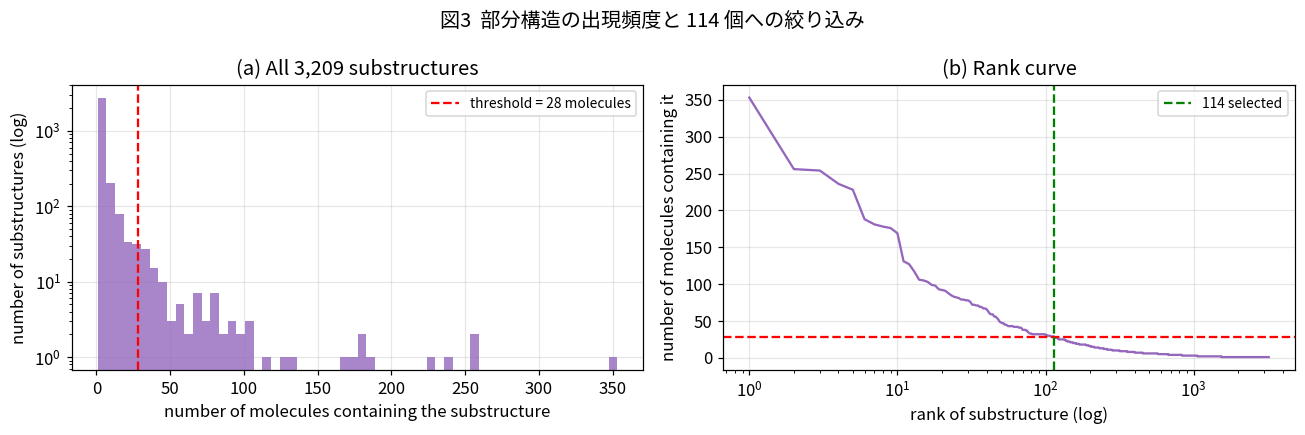

最も多くの分子に現れる部分構造は 353 / 353 分子に出現
1分子にしか現れない部分構造の数: 1670 (52%)


In [16]:
# 出現分子数の分布を見て、114 という数がどこで切られているか確認する
n_molecules_with = (vocabulary['counts'] > 0).sum(axis=0).sort_values(ascending=False)
threshold = len(mols) - MAX_ZEROS

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(n_molecules_with, bins=60, color='tab:purple', alpha=0.8)
axes[0].axvline(threshold, color='red', linestyle='--', label=f'threshold = {threshold} molecules')
axes[0].set_yscale('log')
axes[0].set_xlabel('number of molecules containing the substructure')
axes[0].set_ylabel('number of substructures (log)')
axes[0].set_title('(a) All 3,209 substructures')
axes[0].legend(fontsize=9)

axes[1].plot(np.arange(1, len(n_molecules_with) + 1), n_molecules_with.values, color='tab:purple')
axes[1].axhline(threshold, color='red', linestyle='--')
axes[1].axvline(114, color='green', linestyle='--', label='114 selected')
axes[1].set_xscale('log')
axes[1].set_xlabel('rank of substructure (log)')
axes[1].set_ylabel('number of molecules containing it')
axes[1].set_title('(b) Rank curve')
axes[1].legend(fontsize=9)

fig.suptitle('図3  部分構造の出現頻度と 114 個への絞り込み')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig03_substructure_frequency.png')
plt.show()

print(f"最も多くの分子に現れる部分構造は {n_molecules_with.iloc[0]} / {len(mols)} 分子に出現")
print(f"1分子にしか現れない部分構造の数: {(n_molecules_with == 1).sum()} "
      f"({(n_molecules_with == 1).mean() * 100:.0f}%)")

図3(a) の対数目盛りに注目してください。**大半の部分構造は数分子にしか現れません**。これらを特徴量に入れても、その部分構造を持たない分子については何の情報にもならず、過学習の原因になるだけです。図3(b) の赤線と緑線の交点が、論文の114個という選択に対応します。

### 3.3 特徴量行列をつくり、論文のファイルと照合する

In [17]:
mff = compute_mff(mols, vocabulary, radius=MORGAN_RADIUS)
reference_fing = load_features(DATA_DIR, 'fing')

print(f"今回計算した MFF        : {mff.shape}")
print(f"同梱の datasetAX_fing.csv: {reference_fing.shape}")
print()
print(f"列名が一致          : {list(mff.columns) == list(reference_fing.columns)}")
print(f"値が完全に一致      : {np.array_equal(mff.to_numpy(), reference_fing.to_numpy())}")

assert np.array_equal(mff.to_numpy(), reference_fing.to_numpy())
print()
print("著者らの特徴量ファイルを、SMILES からビット単位で完全に再現できました。")

今回計算した MFF        : (353, 114)
同梱の datasetAX_fing.csv: (353, 114)

列名が一致          : True
値が完全に一致      : True

著者らの特徴量ファイルを、SMILES からビット単位で完全に再現できました。


**これは重要な結果です。**

記述子の方は RDKit のバージョン差で完全一致しませんでしたが、MFF は 2020 年のコードと現在の RDKit で**まったく同じ値**が得られました。Morgan アルゴリズムのハッシュ関数が変わっていないためです。

第3回以降で学習済みモデルを再利用できるのは、この一致が確認できているからです。（入力の意味が変わっていたら、学習済みの重みを使っても正しい予測は出ません。）

### 3.4 部分構造を「見る」

MFF の各列がどんな部分構造なのかを描画してみましょう。論文 Fig.4 で最重要とされた**部分構造 2854（メチル基）**を確認します。

列 2854 | hash=2246728737 | 236/353 分子に出現 | methyl group（論文: 最重要。疎水性と立体障害で透過性を上げる）


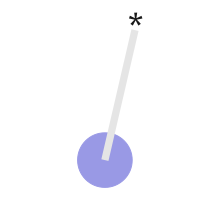

列 2168 | hash=1861965050 |  52/353 分子に出現 | quaternary carbon on aliphatic ring（論文: 透過性を上げる）


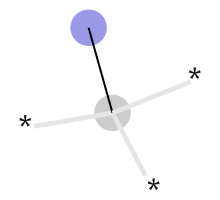

列 1781 | hash=1298690312 |  98/353 分子に出現 | connection bond（論文: ラダーポリマーの結合点の数と相関）


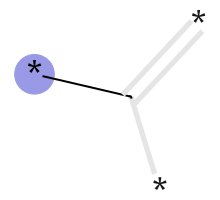

列 2706 | hash= 864942730 | 188/353 分子に出現 | double-bonded oxygen（論文: 極性基。透過性を下げるが選択性に寄与）


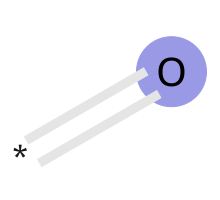

列 1519 | hash= 533204632 | 105/353 分子に出現 | ether（論文: 極性基）


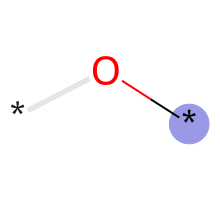

列 2906 | hash= 847961216 |  40/353 分子に出現 | nitrogen atom（論文: 極性基）


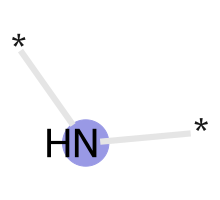

In [18]:
from IPython.display import SVG, display

# 論文 Fig.4 で言及されている部分構造の列番号
paper_substructures = {
    2854: 'methyl group（論文: 最重要。疎水性と立体障害で透過性を上げる）',
    2168: 'quaternary carbon on aliphatic ring（論文: 透過性を上げる）',
    1781: 'connection bond（論文: ラダーポリマーの結合点の数と相関）',
    2706: 'double-bonded oxygen（論文: 極性基。透過性を下げるが選択性に寄与）',
    1519: 'ether（論文: 極性基）',
    2906: 'nitrogen atom（論文: 極性基）',
}

selected_index = list(vocabulary['selected_index'])
for column_index, description in paper_substructures.items():
    position = selected_index.index(column_index)
    hash_code = int(vocabulary['selected_hash'][position])
    host = find_molecule_with_substructure(mols, hash_code)
    n_molecules = int((vocabulary['counts'][column_index] > 0).sum())
    print(f"列 {column_index:>4d} | hash={hash_code:>10d} | {n_molecules:>3d}/353 分子に出現 | {description}")
    svg = draw_substructure(host, hash_code)
    if svg is not None:
        display(SVG(svg))

**図4**　論文 Fig.4 で重要とされた部分構造。青が着目原子、黄色が芳香族原子、灰色が脂肪族環の原子です。列2854 が確かにメチル基（末端の炭素）であることが確認できます。

このように **MFF は「どの部分構造が効いているか」を化学者が目で見て確認できる**という大きな利点があります。第4回の SHAP 解析では、この性質を使って「どんな官能基を入れれば透過性が上がるか」という設計指針を引き出します。

---
## 4. 2つの表現を比べる

In [19]:
descriptor_values = reference_desc.to_numpy(dtype=float)
mff_values = mff.to_numpy(dtype=float)

comparison = pd.DataFrame([
    {'representation': 'RDKit descriptors', 'n_features': descriptor_values.shape[1],
     'sparsity': float((descriptor_values == 0).mean()),
     'value_range': f'{descriptor_values.min():.3g} .. {descriptor_values.max():.3g}',
     'interpretable': 'yes (named physicochemical quantities)',
     'needs_scaling': 'yes'},
    {'representation': 'Morgan fingerprint (MFF)', 'n_features': mff_values.shape[1],
     'sparsity': float((mff_values == 0).mean()),
     'value_range': f'{mff_values.min():.3g} .. {mff_values.max():.3g}',
     'interpretable': 'yes (drawable substructures)',
     'needs_scaling': 'no (already counts on a common scale)'},
])
comparison.to_csv(OUTPUT_DIR / 'representation_comparison.csv', index=False)
comparison

,representation,n_features,sparsity,value_range,interpretable,needs_scaling
0,RDKit descriptors,146,0.496527,-23.8 .. 4.49e+26,yes (named physicochemical quantities),yes
1,Morgan fingerprint (MFF),114,0.810298,0 .. 37,yes (drawable substructures),no (already counts on a common scale)


重要な違いは**値のスケール**です。

- 記述子は分子量（数百）から極性表面積（数十）、環の数（0〜10）まで**桁がバラバラ**なので、学習前に標準化が必須です
- MFF はすべて「出現回数」なので**もともとスケールが揃っている**。原著コードもMFF のときだけ標準化をスキップしています（`step3_train.py` を参照）

これは第3回で実際にコードとして現れます。

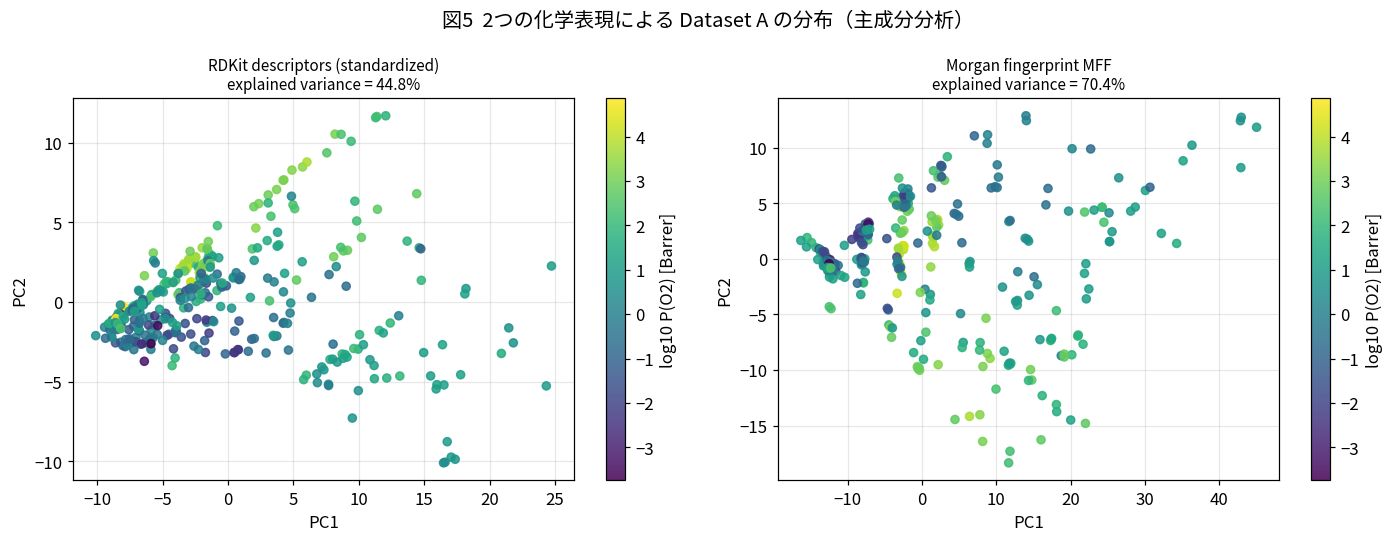

In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from module.pgm_data import get_targets

targets = get_targets(dataset_a, 'BLR')
color_values = targets['log10_O2_Bayesian'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, matrix, scale) in zip(axes, [
        ('RDKit descriptors (standardized)', descriptor_values, True),
        ('Morgan fingerprint MFF', mff_values, False)]):
    data = StandardScaler().fit_transform(matrix) if scale else matrix
    pca = PCA(n_components=2, random_state=42)
    projected = pca.fit_transform(data)
    scatter = ax.scatter(projected[:, 0], projected[:, 1], c=color_values,
                         cmap='viridis', s=28, alpha=0.85)
    ax.set_title(f'{name}\nexplained variance = '
                 f'{pca.explained_variance_ratio_[:2].sum() * 100:.1f}%', fontsize=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    fig.colorbar(scatter, ax=ax, label='log10 P(O2) [Barrer]')

fig.suptitle('図5  2つの化学表現による Dataset A の分布（主成分分析）')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig05_representation_pca.png')
plt.show()

どちらの表現でも、**透過係数の高い高分子（黄色）が空間の特定の領域に集まっています**。つまり「化学構造から透過係数が予測できる」という前提自体は妥当だと確認できます。

なお論文は同じ確認を UMAP（fig. S2）で行っており、Dataset A が Dataset B/C/D の化学空間をおおむね覆っていることを示しています。学習した領域の外へ外挿しすぎていないか、という確認です。

---
## 5. 特徴量を保存する

第3回以降で使うため、計算した特徴量を `output/` に保存しておきます。**位置番号ではなく意味のある名前**を一緒に保存するのがポイントです（2.2節の教訓）。

In [21]:
import json
from rdkit import __version__ as rdkit_version

mff.to_csv(OUTPUT_DIR / 'datasetA_mff_reproduced.csv', index=False)
descriptor_map.to_csv(OUTPUT_DIR / 'descriptor_name_map.csv', index=False)

vocabulary_record = {
    'radius': MORGAN_RADIUS,
    'max_zeros': MAX_ZEROS,
    'n_substructures_total': len(vocabulary['hash_codes']),
    'n_selected': len(vocabulary['selected_index']),
    'column_to_hash': {str(int(c)): int(h) for c, h
                       in zip(vocabulary['selected_index'], vocabulary['selected_hash'])},
    'rdkit_version': rdkit_version,
}
with open(OUTPUT_DIR / 'mff_vocabulary.json', 'w', encoding='utf-8') as handle:
    json.dump(vocabulary_record, handle, indent=1)

print('保存しました:')
for name in ['datasetA_mff_reproduced.csv', 'descriptor_name_map.csv', 'mff_vocabulary.json']:
    print(f'  output/{name}')

保存しました:
  output/datasetA_mff_reproduced.csv
  output/descriptor_name_map.csv
  output/mff_vocabulary.json


---
## 6. まとめ

### 6.1 2つの化学表現の比較（再掲）

| | RDKit 分子記述子 | Morgan フィンガープリント (MFF) |
| --- | --- | --- |
| 次元数 | 146（論文当時）／155（現行RDKitで同じ手続きを踏んだ場合） | 114 |
| 中身 | 分子量・環の数・極性表面積など | 部分構造の出現回数 |
| 解釈のしかた | 記述子名から物理的意味を読む | 部分構造を描いて見る |
| スケール | バラバラ（標準化が必要） | 揃っている（標準化不要） |
| バージョン間の再現性 | **一部一致せず**（記述子の定義変更） | **完全一致** |
| 論文での予測性能（テスト R²） | 約0.89 | 約0.90（わずかに良い） |

### 6.2 本ノートブックのまとめ

1. SMILES から機械学習用の数値ベクトルを作る方法を2通り実装した
2. 記述子は「NaN列・全ゼロ列を落とす」前処理で 217 → 155 次元になった。論文当時（208個の記述子）は同じ手続きで146次元だった
3. MFF は radius=3 で 3,209 種の部分構造を検出し、28分子以上に現れる **114 種**に絞った
4. **著者らの `datasetAX_fing.csv` をビット単位で完全に再現**できた。一方 `datasetAX_desc.csv` は列の意味が位置番号でしか分からず、値照合で143/146列を特定、残り3列は RDKit の定義変更で完全一致しなかった
5. 特徴量ファイルには**必ず名前とバージョンを添えて保存する**（本回最大の実務的教訓）

### 6.3 本ノートブックで扱っていないこと

- **他の化学表現**：SMILES を直接入力する RNN/Transformer、分子グラフを扱うグラフニューラルネットワーク（GNN）など。論文はこれらも試したが「notable performance gains は観測されなかった」と述べている（Discussion 節）
- **高分子特有の表現**：本研究は繰り返し単位1個を「ただの分子」として扱っている。実際の高分子は鎖長・分岐・立体規則性・結晶性などに性能が左右されるが、それらは表現に入っていない
- **3次元的な情報**：立体配座、自由体積の直接計算など。論文はこれを「今後 MD シミュレーションから微細構造の特徴量を足す余地がある」と述べている
- **フィンガープリントの折り畳み（folding）**：一般的な Morgan フィンガープリントは2048ビットなどに畳み込むが、本研究は畳み込まずに頻度を保持している

---
## 7. 演習問題

**問1.** `MAX_ZEROS` を 300 と 340 に変えて `build_mff_vocabulary()` を実行し、選ばれる部分構造の数がどう変わるか調べてください。特徴量が多すぎる／少なすぎる場合に何が起きると予想されますか。

**問2.** `MORGAN_RADIUS` を 1 と 2 に変えて、検出される部分構造の総数がどう変わるか調べてください。半径を大きくすると何が捉えられるようになりますか。

**問3.** 図5の PCA で、記述子の場合だけ `StandardScaler` を適用しました。標準化せずに PCA を実行するとどうなるか試し、なぜそうなるか説明してください。

**問4.** `descriptor_map` を使って、`datasetAX_desc.csv` の列を記述子名に付け替えたDataFrame を作り、`MolLogP` と `TPSA` の散布図を描いてください。これらの記述子は何を表していますか。

**問5（発展）.** MFF の「出現回数をそのまま使う」方式と、0/1 のビットベクトル（`GetFingerprint`）を使う方式で、第3回のモデルの精度がどう変わるか予想を立ててください。実際に検証するのは第3回を終えてからでも構いません。

---
### 次回予告

第3回では、いよいよモデルを学習します。まず欠損値補完（MICE / BLR / ERT）の考え方を扱い、次にランダムフォレストと DNN アンサンブルを比較して、論文 Table 2 の数値を再現します。

### 参考文献

1. J. Yang et al., *Sci. Adv.* **8**, eabn9545 (2022).
2. D. Rogers, M. Hahn, "Extended-connectivity fingerprints", *J. Chem. Inf. Model.* **50**, 742-754 (2010). DOI: 10.1021/ci100050t
3. L. Tao, G. Chen, Y. Li, "Machine learning discovery of high-temperature polymers", *Patterns* **2**, 100225 (2021). DOI: 10.1016/j.patter.2021.100225（MFF の考え方の初出）
4. RDKit ドキュメント: https://www.rdkit.org/docs/